In [9]:
import re
import matplotlib.pyplot as plt
import numpy as np

# 1. Obtenha as correções dos cálculos de frequências

In [15]:
def read_orca_thermo(source):
    if isinstance(source, str) and '\n' in source:
        lines = source.splitlines()
    else:
        with open(source, 'r') as f:
            lines = f.readlines()

    label_map = {
        "Electronic energy": "electronic_energy",
        "Zero point energy": "zero_point_energy",
        "Thermal vibrational correction": "thermal_vibrational_correction",
        "Thermal rotational correction": "thermal_rotational_correction",
        "Thermal translational correction": "thermal_translational_correction",
        "Thermal Enthalpy correction": "thermal_enthalpy_correction",
        "Total Enthalpy": "total_enthalpy",
        "Electronic entropy": "electronic_entropy",
        "Vibrational entropy": "vibrational_entropy",
        "Rotational entropy": "rotational_entropy",
        "Translational entropy": "translational_entropy",
        "Final entropy term": "final_entropy_term",
    }

    result_thermo = {key: None for key in label_map.values()}

    for line in lines:
        line_stripped = line.strip()
        if not line_stripped:
            continue

        for label, key in label_map.items():
            if label in line:
                floats = re.findall(r"[-+]?\d*\.\d+|\d+", line)
                if floats:
                    result_thermo[key] = float(floats[0])
                break

    return result_thermo

# 2. Obtenha a energia eletrônica final de um cálculo de energia em nível mais avançado

In [16]:
def read_orca_energy(source):

    if isinstance(source, str) and '\n' in source:
        lines = source.splitlines()
    else:
        with open(source, 'r') as f:
            lines = f.readlines()

    label_map = {"FINAL SINGLE POINT ENERGY":"electronic_energy"}

    result_sp = {key: None for key in label_map.values()}

    for line in lines:
        line_stripped = line.strip()
        if not line_stripped:
            continue

        for label, key in label_map.items():
            if label in line:
                floats = re.findall(r"[-+]?\d*\.\d+|\d+", line)
                if floats:
                    result_sp[key] = float(floats[0])
                break

    return result_sp

# 3. Execute as funções e armazene os dados em dicionários

In [17]:
path = "/content/drive/MyDrive/Colab Notebooks/Cinetica/TS_search/"

In [18]:
thermo_ts = read_orca_thermo(path + "01_optts/freq.out")
thermo_r  = read_orca_thermo(path + "03_opt_endpoints/freq_R.out")
thermo_p  = read_orca_thermo(path + "03_opt_endpoints/freq_P.out")

sp_ts = read_orca_energy(path + "04_single_points/sp_ts.out")
sp_r  = read_orca_energy(path + "04_single_points/sp_r.out")
sp_p  = read_orca_energy(path + "04_single_points/sp_p.out")

# 4. Obtenha a entalpia, a componente entrópica e a energia livre de cada ponto da coordenada

In [21]:
### Data for R ###

U_R = sp_r["electronic_energy"] + \
      thermo_r["zero_point_energy"] + \
      thermo_r["thermal_vibrational_correction"] + \
      thermo_r["thermal_rotational_correction"] + \
      thermo_r["thermal_translational_correction"]

H_R = U_R + thermo_r["thermal_enthalpy_correction"]

S_R = thermo_r["electronic_entropy"] + \
      thermo_r["vibrational_entropy"] + \
      thermo_r["rotational_entropy"] + \
      thermo_r["translational_entropy"]

G_R = H_R - S_R

### Data for TS ###

U_TS = sp_ts["electronic_energy"] + \
       thermo_ts["zero_point_energy"] + \
       thermo_ts["thermal_vibrational_correction"] + \
       thermo_ts["thermal_rotational_correction"] + \
       thermo_ts["thermal_translational_correction"]

H_TS = U_TS + thermo_ts["thermal_enthalpy_correction"]

S_TS = thermo_ts["electronic_entropy"] + \
       thermo_ts["vibrational_entropy"] + \
       thermo_ts["rotational_entropy"] + \
       thermo_ts["translational_entropy"]

G_TS = H_TS - S_TS

### Data for P ###

U_P = sp_p["electronic_energy"] + \
      thermo_p["zero_point_energy"] + \
      thermo_p["thermal_vibrational_correction"] + \
      thermo_p["thermal_rotational_correction"] + \
      thermo_p["thermal_translational_correction"]

H_P = U_P + thermo_p["thermal_enthalpy_correction"]

S_P = thermo_p["electronic_entropy"] + \
      thermo_p["vibrational_entropy"] + \
      thermo_p["rotational_entropy"] + \
      thermo_p["translational_entropy"]

G_P = H_P - S_P

# 5. Obtenha os valores em relação ao reagente

In [22]:
print(U_R, U_TS, U_P)
print(H_R, H_TS, H_P)
print(S_R, S_TS, S_P)
print(G_R, G_TS, G_P)

print()

U  = [ U_R, U_TS, U_P ]
H  = [ H_R, H_TS, H_P ]
S  = [ S_R, S_TS, S_P ]
G  = [ G_R, G_TS, G_P ]

print(U)
print(H)
print(S)
print(G)

print()

dU = [ (x - U_R) * 627.509 for x in U ]
dH = [ (x - H_R) * 627.509 for x in H ]
dS = [ (x - S_R) * 627.509 for x in S ]
dG = [ (x - G_R) * 627.509 for x in G ]

print(dU)
print(dH)
print(dS)
print(dG)

-2689.7171857694534 -2689.704586991766 -2689.7638319264233
-2689.7162415594535 -2689.703642781766 -2689.7628877164234
0.0383187 0.03542238 0.03746139
-2689.7545602594537 -2689.739065161766 -2689.8003491064233

[-2689.7171857694534, -2689.704586991766, -2689.7638319264233]
[-2689.7162415594535, -2689.703642781766, -2689.7628877164234]
[0.0383187, 0.03542238, 0.03746139]
[-2689.7545602594537, -2689.739065161766, -2689.8003491064233]

[0.0, 7.905846387807803, -29.270883314042354]
[0.0, 7.905846387807803, -29.270883314042354]
[0.0, -1.8174668668799963, -0.53796974079]
[0.0, 9.723313254824669, -28.732913573029]


# 6. Represente graficamente



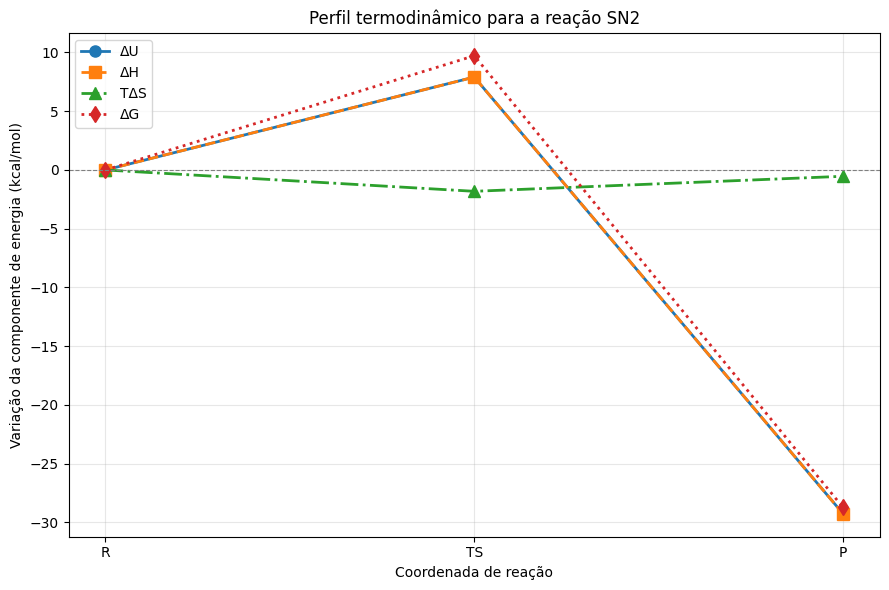

In [27]:
x      = [0, 1, 2]
labels = ['R', 'TS', 'P']

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(x, dU, 'o-', label='ΔU', linewidth=2, markersize=8)
ax.plot(x, dH, 's--', label='ΔH', linewidth=2, markersize=8)
ax.plot(x, dS, '^-.', label='TΔS', linewidth=2, markersize=8)
ax.plot(x, dG, 'd:', label='ΔG', linewidth=2, markersize=8)

ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel('Coordenada de reação')

ax.set_ylabel('Variação da componente de energia (kcal/mol)')
ax.set_title('Perfil termodinâmico para a reação SN2')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()